# 02 - Time Split & Feature Engineering (Industry Standard Pipeline)
**IS5126 Cross-Regional PD Model Transferability Study**

**Key principle:** All feature transformations are fit on TRAINING data only, then applied to test. This prevents data leakage — the #1 disqualifier in credit risk model validation.

Pipeline:
1. Load data + recover issue dates for time split
2. **Time-based train/test split** (train: pre-2017, test: 2017+)
3. Remove leakage & redundant features
4. Missing value imputation (fit on train)
5. Derived ratio features
6. Categorical encoding — WOE (computed on train)
7. Hybrid emp_title classification (Rule + LLM)
8. IV analysis (on train)
9. Save train/test separately

## 0. Setup

In [1]:
!pip install -q category_encoders shap lightgbm xgboost openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import json
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

COLORS = {
    'primary': '#1F4E79', 'accent': '#2E86AB',
    'good': '#28A745', 'bad': '#DC3545', 'neutral': '#6C757D',
}

os.makedirs('figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

print('Setup complete!')

Setup complete!


## 1. Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/is5126'

df = pd.read_parquet(f'{DRIVE_DIR}/data/processed/lending_club_cleaned.parquet')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Default rate: {df["default"].mean()*100:.2f}%')

Mounted at /content/drive
Loaded: 1,366,817 rows x 91 columns
Default rate: 21.22%


In [4]:
df['issue_date'] = pd.to_datetime(df['issue_d'], format='mixed', errors='coerce')
df = df.drop(columns=['issue_d'])
df = df.dropna(subset=['issue_date'])

## 2. Time-Based Train/Test Split

**Why time split?** In production credit risk, you always predict future borrowers using historical models. Random split lets the model see future patterns — this is leakage.

**Split:** Train on pre-2017 loans, test on 2017+. Simulates deploying a model built in late 2016.

In [5]:
CUTOFF = pd.Timestamp('2017-01-01')

train_mask = df['issue_date'] < CUTOFF
test_mask = df['issue_date'] >= CUTOFF

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

print(f'Time split at {CUTOFF.date()}')
print(f'Train: {len(df_train):,} rows ({df_train["issue_date"].min().date()} to {df_train["issue_date"].max().date()})')
print(f'  Default rate: {df_train["default"].mean()*100:.2f}%')
print(f'Test:  {len(df_test):,} rows ({df_test["issue_date"].min().date()} to {df_test["issue_date"].max().date()})')
print(f'  Default rate: {df_test["default"].mean()*100:.2f}%')
print(f'Train/Test ratio: {len(df_train)/len(df)*100:.0f}/{len(df_test)/len(df)*100:.0f}')

Time split at 2017-01-01
Train: 1,125,953 rows (2007-06-01 to 2016-12-01)
  Default rate: 20.14%
Test:  240,864 rows (2017-01-01 to 2018-12-01)
  Default rate: 26.27%
Train/Test ratio: 82/18


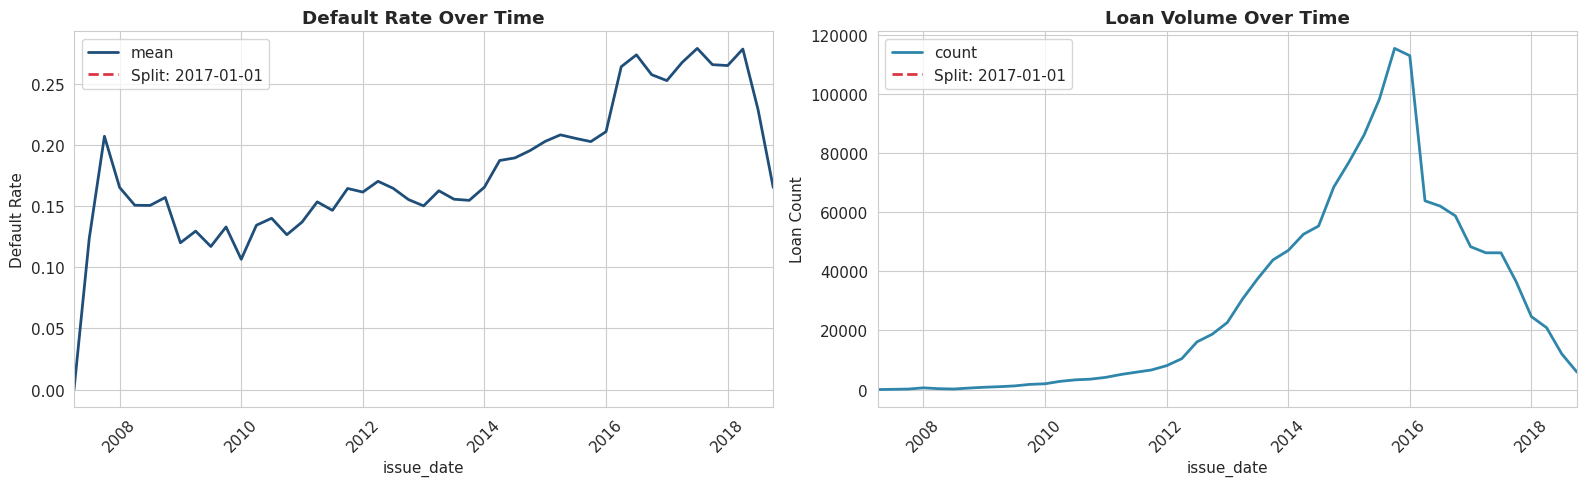


Note: Default rate difference between train/test is expected and tests model robustness to temporal drift.


In [6]:
# Visualize train/test boundary
quarterly = df.groupby(df['issue_date'].dt.to_period('Q'))['default'].agg(['mean', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
quarterly['mean'].plot(ax=ax, color=COLORS['primary'], linewidth=2)
try:
    split_loc = list(quarterly.index).index(pd.Period('2017Q1', 'Q'))
    ax.axvline(x=split_loc, color=COLORS['bad'], linewidth=2, linestyle='--', label=f'Split: {CUTOFF.date()}')
except ValueError:
    pass
ax.set_ylabel('Default Rate')
ax.set_title('Default Rate Over Time', fontweight='bold')
ax.legend()
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
quarterly['count'].plot(ax=ax, color=COLORS['accent'], linewidth=2)
try:
    ax.axvline(x=split_loc, color=COLORS['bad'], linewidth=2, linestyle='--', label=f'Split: {CUTOFF.date()}')
except:
    pass
ax.set_ylabel('Loan Count')
ax.set_title('Loan Volume Over Time', fontweight='bold')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/08_time_split.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNote: Default rate difference between train/test is expected and tests model robustness to temporal drift.')

In [7]:
# Drop issue_date (not a modeling feature)
df_train = df_train.drop(columns=['issue_date'])
df_test = df_test.drop(columns=['issue_date'])

## 3. Remove Leakage & Redundant Features

In [8]:
leakage_cols = ['last_fico_range_low', 'last_fico_range_high',
                'pymnt_plan', 'disbursement_method']

multicollinear_drops = [
    'fico_range_low', 'fico_range_high',
    'num_sats', 'num_rev_tl_bal_gt_0',
    'tot_hi_cred_lim', 'total_il_high_credit_limit',
    'bc_open_to_buy', 'total_bc_limit',
    'num_op_rev_tl', 'total_bal_ex_mort',
    'emp_length', 'earliest_cr_line',
]

all_drops = leakage_cols + multicollinear_drops
existing_drops = [c for c in all_drops if c in df_train.columns]

df_train = df_train.drop(columns=existing_drops)
df_test = df_test.drop(columns=existing_drops)

print(f'Dropped {len(existing_drops)} columns')
print(f'Train: {df_train.shape}, Test: {df_test.shape}')

Dropped 16 columns
Train: (1125953, 74), Test: (240864, 74)


## 4. Feature Cleaning (Deterministic)

In [9]:
def clean_features(df):
    """Deterministic cleaning — same logic for train and test."""
    df = df.copy()
    if df['int_rate'].dtype == 'object':
        df['int_rate'] = df['int_rate'].str.rstrip('%').astype(float)
    if 'revol_util' in df.columns and df['revol_util'].dtype == 'object':
        df['revol_util'] = df['revol_util'].str.rstrip('%').astype(float)
    if df['term'].dtype == 'object':
        df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)
    return df

df_train = clean_features(df_train)
df_test = clean_features(df_test)
print(f'Cleaned. Train: {df_train.shape}, Test: {df_test.shape}')

Cleaned. Train: (1125953, 74), Test: (240864, 74)


## 5. Missing Value Imputation (Fit on Train Only)

In [10]:
numeric_features = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [c for c in numeric_features if c != 'default']
categorical_features = df_train.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric: {len(numeric_features)}, Categorical: {len(categorical_features)}')
print(f'Categorical: {categorical_features}')

Numeric: 64, Categorical: 9
Categorical: ['grade', 'sub_grade', 'emp_title', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']


In [11]:
# Drop columns with > 70% missing in TRAIN
train_missing = df_train[numeric_features].isnull().mean()
high_missing = train_missing[train_missing > 0.70].index.tolist()
if high_missing:
    print(f'Dropping {len(high_missing)} columns with >70% missing in train:')
    for col in high_missing:
        print(f'  {col}: {train_missing[col]*100:.1f}%')
    df_train = df_train.drop(columns=high_missing)
    df_test = df_test.drop(columns=high_missing)
    numeric_features = [c for c in numeric_features if c not in high_missing]
else:
    print('No columns with >70% missing.')
print(f'Train: {df_train.shape}, Test: {df_test.shape}')

Dropping 14 columns with >70% missing in train:
  open_acc_6m: 71.9%
  open_act_il: 71.9%
  open_il_12m: 71.9%
  open_il_24m: 71.9%
  mths_since_rcnt_il: 72.6%
  total_bal_il: 71.9%
  il_util: 75.5%
  open_rv_12m: 71.9%
  open_rv_24m: 71.9%
  max_bal_bc: 71.9%
  all_util: 71.9%
  inq_fi: 71.9%
  total_cu_tl: 71.9%
  inq_last_12m: 71.9%
Train: (1125953, 60), Test: (240864, 60)


In [12]:
# Missing flags (based on TRAIN rates)
train_miss_rates = df_train[numeric_features].isnull().mean()
flag_features = train_miss_rates[train_miss_rates > 0.01].index.tolist()

print(f'Adding missing flags for {len(flag_features)} features:')
for col in flag_features:
    df_train[f'{col}_missing'] = df_train[col].isnull().astype(int)
    df_test[f'{col}_missing'] = df_test[col].isnull().astype(int)
    print(f'  {col}_missing: train={df_train[f"{col}_missing"].mean()*100:.1f}%, test={df_test[f"{col}_missing"].mean()*100:.1f}%')

Adding missing flags for 29 features:
  mths_since_last_delinq_missing: train=50.3%, test=51.0%
  tot_coll_amt_missing: train=6.0%, test=0.0%
  tot_cur_bal_missing: train=6.0%, test=0.0%
  total_rev_hi_lim_missing: train=6.0%, test=0.0%
  acc_open_past_24mths_missing: train=4.2%, test=0.0%
  avg_cur_bal_missing: train=6.0%, test=0.0%
  bc_util_missing: train=5.2%, test=1.5%
  mo_sin_old_il_acct_missing: train=8.8%, test=2.9%
  mo_sin_old_rev_tl_op_missing: train=6.0%, test=0.0%
  mo_sin_rcnt_rev_tl_op_missing: train=6.0%, test=0.0%
  mo_sin_rcnt_tl_missing: train=6.0%, test=0.0%
  mort_acc_missing: train=4.2%, test=0.0%
  mths_since_recent_bc_missing: train=5.1%, test=1.3%
  mths_since_recent_inq_missing: train=13.7%, test=8.9%
  mths_since_recent_revol_delinq_missing: train=66.4%, test=67.2%
  num_accts_ever_120_pd_missing: train=6.0%, test=0.0%
  num_actv_bc_tl_missing: train=6.0%, test=0.0%
  num_actv_rev_tl_missing: train=6.0%, test=0.0%
  num_bc_sats_missing: train=5.0%, test=0.0%

In [13]:
# Impute with TRAIN medians
impute_values = {}
for col in numeric_features:
    if df_train[col].isnull().any():
        median_val = df_train[col].median()
        impute_values[col] = median_val
        df_train[col] = df_train[col].fillna(median_val)
        df_test[col] = df_test[col].fillna(median_val)

print(f'Imputed {len(impute_values)} features with TRAIN medians')

for col in categorical_features:
    df_train[col] = df_train[col].fillna('Unknown')
    df_test[col] = df_test[col].fillna('Unknown')

assert df_train.isnull().sum().sum() == 0
assert df_test.isnull().sum().sum() == 0
print('No nulls remaining.')

Imputed 36 features with TRAIN medians
No nulls remaining.


In [14]:
# Save imputation values
impute_record = {'numeric_medians': {k: float(v) for k, v in impute_values.items()},
                 'categorical_fill': 'Unknown',
                 'note': 'All medians from TRAIN only (pre-2017)'}
with open(f'{DRIVE_DIR}/data/processed/imputation_values.json', 'w') as f:
    json.dump(impute_record, f, indent=2)
print('Saved imputation values')

Saved imputation values


## 6. Derived Ratio Features (Deterministic)

In [15]:
def create_derived_features(df):
    df = df.copy()
    df['monthly_inc'] = df['annual_inc'] / 12
    df['installment_to_income'] = df['installment'] / (df['monthly_inc'] + 1)
    df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
    if 'tot_cur_bal' in df.columns:
        df['revol_to_total_bal'] = df['revol_bal'] / (df['tot_cur_bal'] + 1)
        df['avg_account_bal'] = df['tot_cur_bal'] / (df['total_acc'] + 1)
    df['delinq_per_year'] = df['delinq_2yrs'] / (df['credit_history_months'] / 12 + 1)
    df['inq_per_open_acc'] = df['inq_last_6mths'] / (df['open_acc'] + 1)
    df['revol_bal_to_income'] = df['revol_bal'] / (df['annual_inc'] + 1)
    if 'acc_open_past_24mths' in df.columns:
        df['new_acc_rate'] = df['acc_open_past_24mths'] / (df['total_acc'] + 1)
    df['is_long_term'] = (df['term'] == 60).astype(int)
    return df

df_train = create_derived_features(df_train)
df_test = create_derived_features(df_test)

derived = ['monthly_inc', 'installment_to_income', 'loan_to_income',
           'revol_to_total_bal', 'avg_account_bal', 'delinq_per_year',
           'inq_per_open_acc', 'revol_bal_to_income', 'new_acc_rate', 'is_long_term']
derived = [f for f in derived if f in df_train.columns]

print(f'Created {len(derived)} derived features.')
for feat in derived:
    corr = df_train[feat].corr(df_train['default'])
    print(f'  {feat:30s} | train corr: {corr:+.4f}')

Created 10 derived features.
  monthly_inc                    | train corr: -0.0404
  installment_to_income          | train corr: +0.0034
  loan_to_income                 | train corr: +0.0020
  revol_to_total_bal             | train corr: +0.0259
  avg_account_bal                | train corr: -0.0614
  delinq_per_year                | train corr: +0.0250
  inq_per_open_acc               | train corr: +0.0495
  revol_bal_to_income            | train corr: +0.0019
  new_acc_rate                   | train corr: +0.1155
  is_long_term                   | train corr: +0.1915


## 7. Categorical Encoding — WOE (Fit on Train Only)

In [16]:
# Ordinal encoding
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
for dset in [df_train, df_test]:
    dset['grade_num'] = dset['grade'].map(grade_map)

sub_grades_train = sorted(df_train['sub_grade'].unique())
sub_grade_map = {sg: i+1 for i, sg in enumerate(sub_grades_train)}
df_train['sub_grade_num'] = df_train['sub_grade'].map(sub_grade_map)
df_test['sub_grade_num'] = df_test['sub_grade'].map(sub_grade_map).fillna(0).astype(int)

print(f'grade_num: 1-7, sub_grade_num: 1-{len(sub_grade_map)}')

grade_num: 1-7, sub_grade_num: 1-35


In [17]:
def calculate_woe_iv(df, feature, target='default'):
    crosstab = pd.crosstab(df[feature], df[target])
    crosstab.columns = ['good', 'bad']
    crosstab['good_pct'] = (crosstab['good'] / crosstab['good'].sum()).clip(lower=0.0001)
    crosstab['bad_pct'] = (crosstab['bad'] / crosstab['bad'].sum()).clip(lower=0.0001)
    crosstab['woe'] = np.log(crosstab['good_pct'] / crosstab['bad_pct'])
    crosstab['iv'] = (crosstab['good_pct'] - crosstab['bad_pct']) * crosstab['woe']
    return crosstab['woe'].to_dict(), crosstab['iv'].sum(), crosstab

woe_features = ['home_ownership', 'verification_status', 'purpose',
                'initial_list_status', 'application_type', 'addr_state']
woe_features = [f for f in woe_features if f in df_train.columns]

woe_maps = {}
iv_results = []

for feat in woe_features:
    woe_map, iv, _ = calculate_woe_iv(df_train, feat)  # FIT ON TRAIN
    woe_maps[feat] = {str(k): float(v) for k, v in woe_map.items()}
    iv_results.append({'feature': feat, 'IV': round(iv, 4)})
    df_train[f'{feat}_woe'] = df_train[feat].map(woe_map).fillna(0)
    df_test[f'{feat}_woe'] = df_test[feat].map(woe_map).fillna(0)  # APPLY TRAIN MAP

print('=== WOE IV (TRAIN only) ===')
print(pd.DataFrame(iv_results).sort_values('IV', ascending=False).to_string(index=False))

=== WOE IV (TRAIN only) ===
            feature    IV
verification_status 0.053
     home_ownership 0.026
            purpose 0.019
         addr_state 0.015
initial_list_status 0.002
   application_type 0.001


In [18]:
with open(f'{DRIVE_DIR}/data/processed/woe_maps.json', 'w') as f:
    json.dump(woe_maps, f, indent=2)
print('Saved WOE maps (train-derived)')

Saved WOE maps (train-derived)


## 8. Hybrid emp_title Classification

In [19]:
def classify_job_title_rules(title):
    if pd.isna(title): return 'Unknown'
    t = str(title).lower().strip()
    if re.search(r'\b(rn|lpn|cna|nurse|nursing|doctor|physician|surgeon|dentist|pharmacist|therapist|paramedic|emt|medical|clinical|health|hospital|dental|optom|chiro|psych|radiol|anesthes|patholog|midwife|phlebotom|caregiver|aide)\b', t): return 'Healthcare'
    if re.search(r'\b(teacher|professor|principal|instructor|tutor|coach|school|education|academic|faculty|librarian|dean|superintendent|counselor)\b', t): return 'Education'
    if re.search(r'\b(software|developer|programmer|engineer.*software|web dev|data scien|data analy|data engineer|machine learn|devops|sysadmin|system admin|network admin|it |it$|information tech|cyber|cloud|database|dba|full.?stack|front.?end|back.?end|sre|qa engineer|test engineer|ux|ui designer)\b', t): return 'Technology'
    if re.search(r'\b(account|cpa|auditor|bookkeeper|finance|financial|banker|loan officer|underwriter|actuary|tax |treasurer|controller|cfo|comptroller|credit analyst|investment|broker|trader)\b', t): return 'Finance_Accounting'
    if re.search(r'\b(attorney|lawyer|paralegal|legal|judge|solicitor|counsel|litigation|law clerk|barrister)\b', t): return 'Legal'
    if re.search(r'\b(military|army|navy|marine|air force|sergeant|colonel|captain|lieutenant|officer.*police|police|sheriff|trooper|detective|federal|government|postal|firefighter|fire fighter|corrections|border patrol|tsa|fbi|cia|dea)\b', t): return 'Government_Military'
    if re.search(r'\b(ceo|coo|cto|cfo|cio|president|vice president|vp |director|executive|partner|founder|owner|chief|gm |general manager)\b', t): return 'Management_Executive'
    if re.search(r'\b(engineer|architect|scientist|researcher|chemist|biologist|physicist|geologist|environmental|civil eng|mechanical eng|electrical eng|chemical eng|aerospace|structural|surveyor|drafter)\b', t): return 'Science_Engineering'
    if re.search(r'\b(sales|realtor|real estate|marketing|advertising|brand|merchandis|buyer|purchasing|business develop|account exec|territory|retail.*manager)\b', t): return 'Sales_Marketing'
    if re.search(r'\b(admin|secretary|receptionist|clerk|office manage|assistant|coordinator|scheduler|dispatcher|hr |human resource|recruiter|payroll)\b', t): return 'Admin_Clerical'
    if re.search(r'\b(driver|truck|mechanic|electrician|plumber|carpenter|welder|machin|warehouse|forklift|construction|hvac|painter|roofer|landscap|janitor|custodian|maintenance|technician|installer|assembl|factory|manufactur|production|operator|laborer)\b', t): return 'Trades_Labor'
    if re.search(r'\b(server|bartender|cook|chef|restaurant|hotel|hospitality|retail|cashier|barista|waitress|waiter|housekeeper|stylist|barber|beautician|customer service|call center|flight attendant)\b', t): return 'Service_Hospitality'
    if re.search(r'\b(manager|supervisor|superintendent|lead|foreman|team lead)\b', t): return 'Management_Executive'
    return 'Other'

df_train['job_category'] = df_train['emp_title'].apply(classify_job_title_rules)
df_test['job_category'] = df_test['emp_title'].apply(classify_job_title_rules)

rules_classified = (df_train['job_category'] != 'Other').mean() * 100
print(f'Stage 1 (Rules): {rules_classified:.1f}% classified in train')

Stage 1 (Rules): 59.1% classified in train


In [20]:
# Stage 2: LLM for frequent unmatched (from TRAIN)
other_train = df_train[df_train['job_category'] == 'Other']['emp_title'].value_counts()
frequent_other = other_train[other_train >= 100].index.tolist()
print(f'Frequent unclassified in train: {len(frequent_other)}')

CACHE_PATH = f'{DRIVE_DIR}/data/processed/llm_title_classifications.json'
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'r') as f:
        llm_classifications = json.load(f)
    print(f'Loaded cache: {len(llm_classifications)} titles')
    missing_titles = [t for t in frequent_other if t not in llm_classifications]
    if missing_titles:
        print(f'Need to classify {len(missing_titles)} new titles')
    else:
        print('All titles cached.')
else:
    llm_classifications = {}
    missing_titles = frequent_other
    print(f'No cache. Need to classify {len(missing_titles)} titles')

Frequent unclassified in train: 247
Loaded cache: 308 titles
Need to classify 5 new titles


In [21]:
# *** SKIP if all titles are cached ***
from openai import OpenAI
from google.colab import userdata

# Use Alibaba DashScope (free) or paste key directly
client = OpenAI(
    api_key=userdata.get('QWEN_API_KEY'),
    base_url='https://apis.iflow.cn/v1'
)

JOB_CATEGORIES = ['Healthcare','Education','Technology','Finance_Accounting',
    'Management_Executive','Legal','Government_Military','Sales_Marketing',
    'Trades_Labor','Service_Hospitality','Science_Engineering','Admin_Clerical','Other']

if missing_titles:
    print(f'Classifying {len(missing_titles)} titles...')
    for i in range(0, len(missing_titles), 80):
        batch = missing_titles[i:i+80]
        titles_text = '\n'.join([f'{j+1}. {t}' for j, t in enumerate(batch)])
        prompt = f"""Classify each job title into exactly ONE category from: {', '.join(JOB_CATEGORIES)}

Job titles:
{titles_text}

Return ONLY a JSON object mapping each title to its category. No explanation."""
        try:
            resp = client.chat.completions.create(
                model='qwen-turbo', messages=[{'role':'user','content':prompt}],
                temperature=0, max_tokens=4000)
            result = resp.choices[0].message.content.strip().replace('```json','').replace('```','').strip()
            llm_classifications.update(json.loads(result))
        except Exception as e:
            print(f'  Error: {e}')
            for t in batch: llm_classifications[t] = 'Other'
    with open(CACHE_PATH, 'w') as f:
        json.dump(llm_classifications, f, indent=2)
    print(f'Saved {len(llm_classifications)} classifications')
else:
    print('No new titles to classify.')

Classifying 5 titles...
Saved 308 classifications


In [22]:
# Apply LLM to both train and test
for dset, name in [(df_train, 'Train'), (df_test, 'Test')]:
    mask = (dset['job_category'] == 'Other') & (dset['emp_title'].isin(llm_classifications))
    dset.loc[mask, 'job_category'] = dset.loc[mask, 'emp_title'].map(llm_classifications)
    classified = (dset['job_category'] != 'Other').mean() * 100
    print(f'{name}: {classified:.1f}% classified')

# WOE for job_category — FIT ON TRAIN
woe_map_job, iv_job, _ = calculate_woe_iv(df_train, 'job_category')
df_train['job_category_woe'] = df_train['job_category'].map(woe_map_job).fillna(0)
df_test['job_category_woe'] = df_test['job_category'].map(woe_map_job).fillna(0)

woe_maps['job_category'] = {str(k): float(v) for k, v in woe_map_job.items()}
with open(f'{DRIVE_DIR}/data/processed/woe_maps.json', 'w') as f:
    json.dump(woe_maps, f, indent=2)

print(f'\njob_category IV (train): {iv_job:.4f}')

Train: 65.0% classified
Test: 72.3% classified

job_category IV (train): 0.0190


## 9. IV Analysis (Train Only)

In [23]:
def calculate_numeric_iv(df, feature, target='default', n_bins=10):
    try:
        df_temp = df[[feature, target]].dropna()
        if df_temp[feature].nunique() <= n_bins:
            df_temp['bin'] = df_temp[feature]
        else:
            df_temp['bin'] = pd.qcut(df_temp[feature], q=n_bins, duplicates='drop')
        crosstab = pd.crosstab(df_temp['bin'], df_temp[target])
        crosstab.columns = ['good', 'bad']
        crosstab['good_pct'] = (crosstab['good'] / crosstab['good'].sum()).clip(lower=0.0001)
        crosstab['bad_pct'] = (crosstab['bad'] / crosstab['bad'].sum()).clip(lower=0.0001)
        crosstab['woe'] = np.log(crosstab['good_pct'] / crosstab['bad_pct'])
        crosstab['iv'] = (crosstab['good_pct'] - crosstab['bad_pct']) * crosstab['woe']
        return crosstab['iv'].sum()
    except:
        return 0

all_numeric = df_train.select_dtypes(include=[np.number]).columns.tolist()
all_numeric = [c for c in all_numeric if c != 'default']

iv_scores = [{'feature': f, 'IV': round(calculate_numeric_iv(df_train, f), 4)} for f in all_numeric]
iv_all = pd.DataFrame(iv_scores).sort_values('IV', ascending=False)

def iv_strength(iv):
    if iv > 0.5: return 'Suspicious'
    elif iv > 0.3: return 'Strong'
    elif iv > 0.1: return 'Medium'
    elif iv > 0.02: return 'Weak'
    else: return 'Not useful'

iv_all['Strength'] = iv_all['IV'].apply(iv_strength)

print('=== Feature IV (TRAIN only) ===')
print(iv_all.head(25).to_string(index=False))
print(f'\nIV >= 0.02: {(iv_all["IV"] >= 0.02).sum()} features')

suspicious = iv_all[iv_all['IV'] > 0.5]
if len(suspicious) > 0:
    print(f'\nWARNING - Suspicious (IV > 0.5):')
    print(suspicious.to_string(index=False))

=== Feature IV (TRAIN only) ===
                feature    IV Strength
          sub_grade_num 0.484   Strong
              grade_num 0.466   Strong
               int_rate 0.448   Strong
           is_long_term 0.204   Medium
                   term 0.204   Medium
             fico_score 0.122   Medium
         loan_to_income 0.117   Medium
           new_acc_rate 0.087     Weak
  installment_to_income 0.086     Weak
   acc_open_past_24mths 0.080     Weak
                    dti 0.076     Weak
     num_tl_op_past_12m 0.055     Weak
verification_status_woe 0.053     Weak
            avg_cur_bal 0.044     Weak
         mo_sin_rcnt_tl 0.035     Weak
              loan_amnt 0.034     Weak
            tot_cur_bal 0.032     Weak
        avg_account_bal 0.031     Weak
        num_actv_rev_tl 0.031     Weak
  mo_sin_rcnt_rev_tl_op 0.029     Weak
            monthly_inc 0.029     Weak
             annual_inc 0.029     Weak
   mths_since_recent_bc 0.028     Weak
  mths_since_recent_inq 0.028   

## 10. Prepare & Save Final Feature Sets

In [24]:
# Drop string columns
string_cols = df_train.select_dtypes(include=['object']).columns.tolist()
print(f'Dropping string columns: {string_cols}')
df_train = df_train.drop(columns=string_cols)
df_test = df_test.drop(columns=string_cols)

# Ensure matching columns
common_cols = sorted(set(df_train.columns) & set(df_test.columns))
df_train = df_train[common_cols]
df_test = df_test[common_cols]

feature_cols = [c for c in common_cols if c != 'default']

assert len(df_train.select_dtypes(exclude=[np.number]).columns) == 0
assert len(df_test.select_dtypes(exclude=[np.number]).columns) == 0

print(f'\nTrain: {df_train.shape[0]:,} x {len(feature_cols)} features')
print(f'Test:  {df_test.shape[0]:,} x {len(feature_cols)} features')
print('All numeric: Yes')

Dropping string columns: ['grade', 'sub_grade', 'emp_title', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type', 'job_category']

Train: 1,125,953 x 98 features
Test:  240,864 x 98 features
All numeric: Yes


In [25]:
# Save
df_train.to_parquet(f'{DRIVE_DIR}/data/processed/train.parquet', index=False)
df_test.to_parquet(f'{DRIVE_DIR}/data/processed/test.parquet', index=False)

feature_metadata = {
    'feature_cols': feature_cols,
    'useful_features_iv': iv_all[iv_all['IV'] >= 0.02]['feature'].tolist(),
    'suspicious_features': iv_all[iv_all['IV'] > 0.5]['feature'].tolist(),
    'derived_features': derived,
    'woe_features': [c for c in feature_cols if c.endswith('_woe')],
    'missing_flags': [c for c in feature_cols if c.endswith('_missing')],
    'grade_related': ['grade_num', 'sub_grade_num', 'int_rate'],
    'target': 'default',
    'train_default_rate': float(df_train['default'].mean()),
    'test_default_rate': float(df_test['default'].mean()),
    'train_n': len(df_train),
    'test_n': len(df_test),
    'time_split': str(CUTOFF.date()),
    'pipeline_note': 'All transformations fit on TRAIN only.'
}

with open(f'{DRIVE_DIR}/data/processed/feature_metadata.json', 'w') as f:
    json.dump(feature_metadata, f, indent=2)

print(f'Saved train ({len(df_train):,}) and test ({len(df_test):,}) to Drive')
print(f'Train default: {df_train["default"].mean()*100:.2f}%, Test default: {df_test["default"].mean()*100:.2f}%')

Saved train (1,125,953) and test (240,864) to Drive
Train default: 20.14%, Test default: 26.27%


## 11. Summary

**Pipeline integrity:**
- [x] Time split first (pre-2017 / 2017+)
- [x] No future leakage (last_fico removed)
- [x] Medians from TRAIN only
- [x] WOE maps from TRAIN only
- [x] Derived features: deterministic formulas
- [x] Train/test saved separately

---

**Next: Notebook 03 — Modeling (with/without grade experiment)**